# Snapshot spectra + Newton–Schulz (cells 0–19 of the original notebook)

Pair index map, raw $M_t$ vs $\tilde M_t$, $S_A/S_B$ spectra, Newton–Schulz
and Polar Express iteration on $\tilde M_t$, plus single-run and cross-run
iteration sweeps.


In [1]:
%load_ext autoreload
%autoreload 2

import json

import numpy as np
import torch
import matplotlib.pyplot as plt

from lora_playground.snapshot_analysis import (
    # snapshot registry + cached loader
    SNAP_ROOT, SNAP_ROOTS, STEPS, STEPS_BY_ROOT,
    RUNS, RUN_A, RUN_B, RUN_C, RUN_D,
    load_snapshot, clear_snapshot_cache,
    # adam-moment / spectrum helpers
    Mtilde, normalized_sigmas, normalized_sigmas_x, stable_rank,
    EPS, BETA1, BETA2,
    # whitening
    spd_half_inv, whitened_NS_input, DELTA_ABS,
    # SSC / polar shape
    _prerescale_unit_op, _polar_uvt, _ssc_svd, _ssc_misr_batched,
    # diagnostic NS iteration (trajectory-returning)
    newton_schulz_polar, polar_express,
)

DEV = SSC_DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEV}')
print(f'active RUNS: {RUNS}')
print(f'default STEPS: {STEPS}')

device: cuda
active RUNS: [('3e-2', 64, 5, 'chord-tight'), ('1e-1', 64, 5, 'chord-tight'), ('1e-3', 256, 10, 'chord-tight-clean'), ('1e-1', 256, 10, 'chord-tight-clean')]
default STEPS: [0, 50, 200, 500, 1000, 2000, 4000]


In [2]:
# Snapshot registry sanity print (defs live in lora_playground.snapshot_analysis.snapshots).
for key, st in STEPS_BY_ROOT.items():
    print(f'{key}: steps={st}')

snap = load_snapshot(2000)
print('# pairs:', len(snap['pair_state']))
print('pair 0 keys:', sorted(snap['pair_state'][0].keys()))
for k in ('A', 'B', 'm_A', 'v_A', 'u_A'):
    t = snap['pair_state'][0][k]
    print(f'  {k:5s} shape={tuple(t.shape)} dtype={t.dtype}')
print('step counter:', snap['pair_state'][0]['step'])


('3e-2', 64, 5, 'chord-tight'): steps=[0, 50, 200, 500, 1000, 2000, 4000]
('1e-1', 64, 5, 'chord-tight'): steps=[0, 50, 200, 500, 1000, 2000, 4000]
('1e-1', 256, 10, 'chord-tight-clean'): steps=[0, 200, 1000, 2000, 4000]
('1e-3', 256, 10, 'chord-tight-clean'): steps=[0, 200, 1000, 2000, 4000]


# pairs: 112
pair 0 keys: ['A', 'B', '_group', '_local_idx', 'last_diag', 'm_A', 'm_B', 'step', 'u_A', 'u_B', 'v_A', 'v_B']
  A     shape=(64, 2048) dtype=torch.float32
  B     shape=(2048, 64) dtype=torch.float32
  m_A   shape=(64, 2048) dtype=torch.float32
  v_A   shape=(64, 2048) dtype=torch.float32
  u_A   shape=(64, 2048) dtype=torch.float32
step counter: 2000


## Pair index → layer name mapping

Pair indices are deterministic given the model + PEFT config, but the names
aren't stored in the snapshot. Recover by instantiating the same model
and calling `collect_lora_pairs_named`. Slow (~30s for OLMo-2-1B); cache the
result for the session.

In [3]:
from lora_playground.utils import collect_lora_pairs_named
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM

def recover_pair_names(lora_r=64):
    base = AutoModelForCausalLM.from_pretrained('allenai/OLMo-2-0425-1B',
                                                torch_dtype=torch.float32)
    cfg = LoraConfig(r=lora_r, lora_alpha=lora_r, target_modules='all-linear',
                     lora_dropout=0.0, init_lora_weights=True)
    model = get_peft_model(base, cfg)
    named = collect_lora_pairs_named(model, adapter_name=None)
    return [n for _, _, n in named]

# Uncomment when you need names. Leave commented for fast iteration.
# PAIR_NAMES = recover_pair_names()
# for i, n in enumerate(PAIR_NAMES[:5]):
#     print(f'  {i:3d}  {n}')

/mnt/home/nghosh/miniforge3/envs/ffcv-pl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Compute $M_t$, $\tilde M_t$ for one pair / one step

$M_t$ is `m_A` post-EMA (already in pair_state). $\tilde M_t$ uses the **paper's
convention** (no bias correction):

$$\tilde M_t = M_t \oslash (\sqrt{V_t} + \varepsilon).$$

Our optimizer's stashed `u_A` is the bias-corrected variant
$\hat M_t / (\sqrt{\hat V_t} + \varepsilon)$ where $\hat M_t = M_t/(1-\beta_1^t)$.
Useful as a sanity-check anchor.

In [4]:
# Mtilde, EPS, BETA1, BETA2 live in lora_playground.snapshot_analysis.moments.
# Sanity: our stashed u_A should match the bc=True recomputation.
PAIR = 0
p = snap['pair_state'][PAIR]
M_A = p['m_A']
Mt_A_paper = Mtilde(p, 'A', bias_correct=False)
Mt_A_ours  = Mtilde(p, 'A', bias_correct=True)
u_A = p['u_A']
drift = (Mt_A_ours - u_A).abs().max().item()
print(f'max |recompute(bc=True) - u_A| = {drift:.2e}')

for name, mat in [('M_t (raw)', M_A),
                  ('M̃_t (paper, no bc)', Mt_A_paper),
                  ('M̃_t (bc, our u_A)', u_A)]:
    s = torch.linalg.svdvals(mat).numpy()
    print(f'{name:28s}  ‖⋅‖_F = {mat.norm().item():9.4f}  '
          f'σ_max = {s[0]:9.4f}  σ_min = {s[-1]:9.4f}  '
          f'eff_rank = {(s.sum()**2 / (s**2).sum()):6.2f}')


max |recompute(bc=True) - u_A| = 1.19e-07
M_t (raw)                     ‖⋅‖_F =    0.0022  σ_max =    0.0009  σ_min =    0.0000  eff_rank =  36.37
M̃_t (paper, no bc)           ‖⋅‖_F =   85.6382  σ_max =   30.3123  σ_min =    2.2088  eff_rank =  44.85
M̃_t (bc, our u_A)            ‖⋅‖_F =   79.6417  σ_max =   28.1898  σ_min =    2.0541  eff_rank =  44.85


## Spectrum of $M_t$ vs $\tilde M_t$ at one step (paper Fig. 1a/1b style)

Frobenius-normalized to remove the global scale factor; the paper's claim is
about the *distribution* of singular values, not their absolute magnitude.

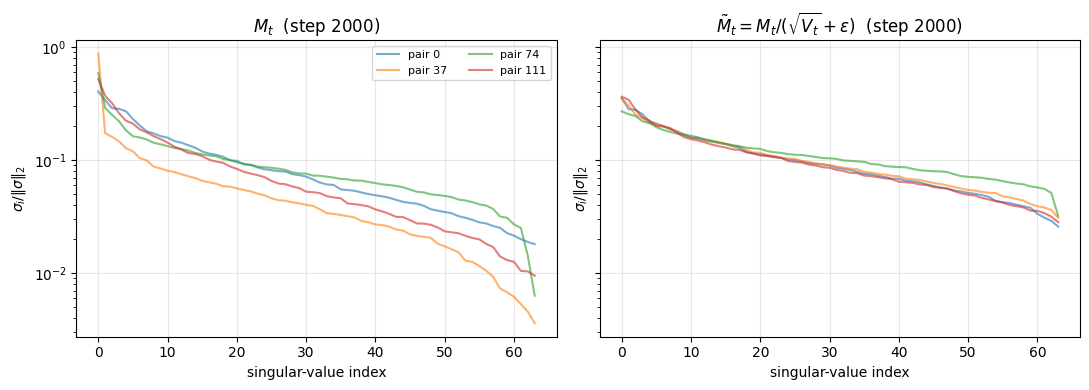

In [5]:
# normalized_sigmas lives in lora_playground.snapshot_analysis.moments.
def plot_spectra(step, pair_indices=None, n_pairs_to_plot=4, side='A'):
    snap = load_snapshot(step)
    n_pairs = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_pairs - 1, n_pairs_to_plot, dtype=int)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
    for pi in pair_indices:
        p = snap['pair_state'][int(pi)]
        s_M = normalized_sigmas(p[f'm_{side}'])
        s_Mt = normalized_sigmas(Mtilde(p, side, bias_correct=False))
        axes[0].plot(s_M,  alpha=0.6, label=f'pair {int(pi)}')
        axes[1].plot(s_Mt, alpha=0.6, label=f'pair {int(pi)}')
    axes[0].set_title(f'$M_t$  (step {step})')
    axes[1].set_title(f'$\\tilde M_t = M_t / (\\sqrt{{V_t}} + \\varepsilon)$  (step {step})')
    for ax in axes:
        ax.set_yscale('log')
        ax.set_xlabel('singular-value index')
        ax.set_ylabel('$\\sigma_i / \\|\\sigma\\|_2$')
        ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=8, ncol=2)
    fig.tight_layout()
    return fig

plot_spectra(2000, n_pairs_to_plot=4, side='A')
plt.show()

## Spectra of $S_A = A A^\top$ and $S_B = B^\top B$

Context for the whitening below: the chord-tight A-side update uses
$S_B^{-1/2}$ as a preconditioner, where $S_B = B^\top B \in \mathbb{R}^{r \times r}$
(symmetric for B-side, $S_A = A A^\top$). Whether whitening helps NS depends
on how poorly conditioned these Gram matrices are.

Eigenvalues of $S_A$, $S_B$ are also $\sigma_i(A)^2$, $\sigma_i(B)^2$ — so this
is equivalently the squared-singular-spectrum of the LoRA factors. Frobenius-
normalized to factor out per-layer scale; raw $\sigma_{\max}$ is reported in
the legend so the absolute scale isn't lost.

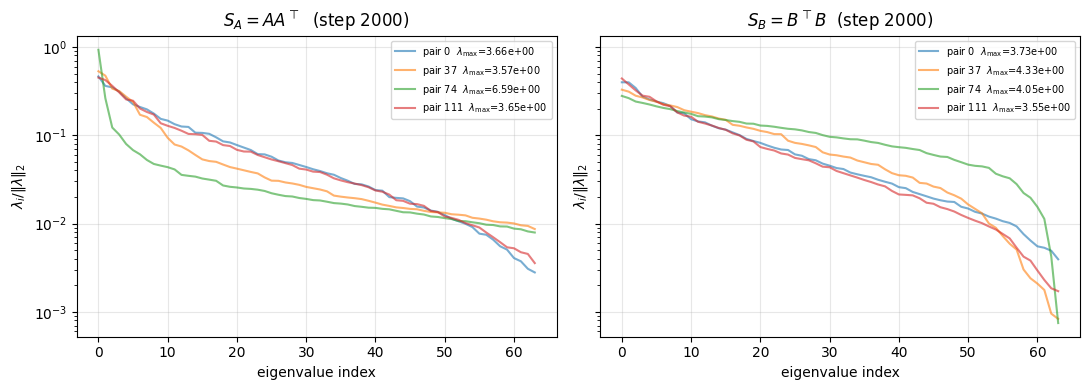

In [6]:
def plot_SA_SB_spectra(step, pair_indices=None, n_pairs_to_plot=4):
    snap = load_snapshot(step)
    n_pairs = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_pairs - 1, n_pairs_to_plot, dtype=int)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
    for pi in pair_indices:
        p = snap['pair_state'][int(pi)]
        A = p['A'].float(); B = p['B'].float()
        eA = torch.linalg.eigvalsh(A @ A.T).clamp_min(0).flip(0).numpy()
        eB = torch.linalg.eigvalsh(B.T @ B).clamp_min(0).flip(0).numpy()
        nA = eA / np.linalg.norm(eA); nB = eB / np.linalg.norm(eB)
        axes[0].plot(nA, alpha=0.6,
                     label=f'pair {int(pi)}  $\\lambda_{{\\max}}$={eA[0]:.2e}')
        axes[1].plot(nB, alpha=0.6,
                     label=f'pair {int(pi)}  $\\lambda_{{\\max}}$={eB[0]:.2e}')
    axes[0].set_title(f'$S_A = A A^\\top$  (step {step})')
    axes[1].set_title(f'$S_B = B^\\top B$  (step {step})')
    for ax in axes:
        ax.set_yscale('log')
        ax.set_xlabel('eigenvalue index')
        ax.set_ylabel(r'$\lambda_i / \|\lambda\|_2$')
        ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
    fig.tight_layout()
    return fig

plot_SA_SB_spectra(2000, n_pairs_to_plot=4)
plt.show()

## NS on $M_t$ vs $\tilde M_t$ (Adam-scaling effect through the NS lens)

The whitening cell above compared raw `u_A` vs whitened input $S_B^{-1/2} u_A$ —
both already post-Adam-scaling. This cell isolates the **Adam scaling step
itself**: run NS on the raw EMA momentum $M_t$ and on the Adam-scaled
$\tilde M_t = M_t / (\sqrt{V_t} + \varepsilon)$ and overlay the resulting
spectra.

Paper Fig. 1a/1b's claim is that $\tilde M_t$ has a much heavier spectrum than
$M_t$, which is what motivates the polar step. Here we ask: does that flatter
input spectrum actually make NS converge — or does NS hit the dead-zone on
both?

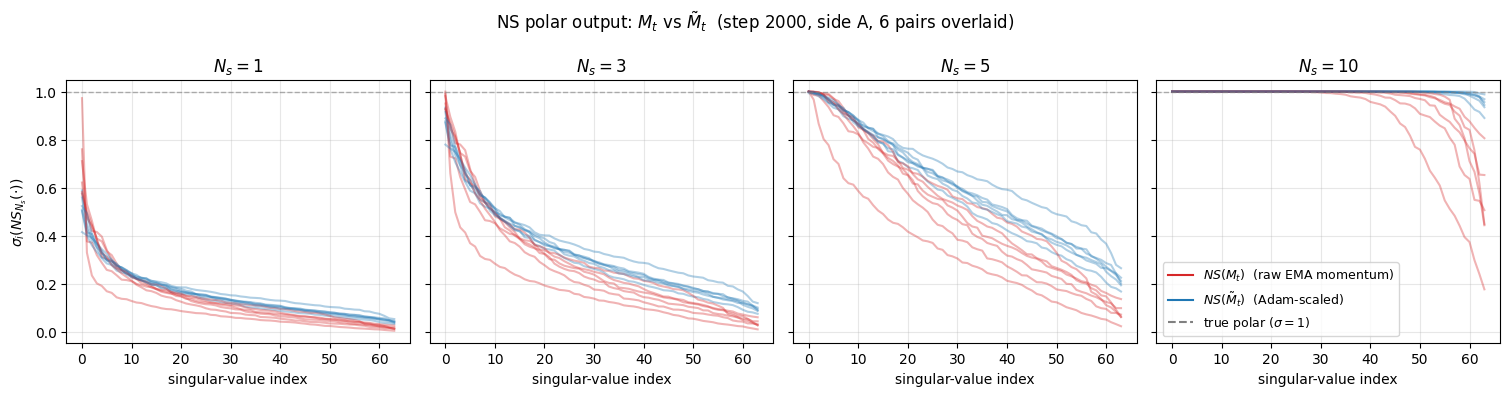

In [7]:
# newton_schulz_polar lives in lora_playground.snapshot_analysis.iteration.
def plot_ns_M_vs_Mtilde(step, pair_indices=None, n_pairs=6, side='A',
                        Ks=(1, 3, 5, 10)):
    snap = load_snapshot(step)
    n_total = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)

    fig, axes = plt.subplots(1, len(Ks), figsize=(3.8 * len(Ks), 4),
                             sharey=True, sharex=True)
    for ax, K in zip(axes, Ks):
        for pi in pair_indices:
            p = snap['pair_state'][int(pi)]
            M  = p[f'm_{side}'].float()
            Mt = Mtilde(p, side, bias_correct=False)
            s_M  = torch.linalg.svdvals(newton_schulz_polar(M,  K)).numpy()
            s_Mt = torch.linalg.svdvals(newton_schulz_polar(Mt, K)).numpy()
            ax.plot(s_M,  color='C3', alpha=0.35)
            ax.plot(s_Mt, color='C0', alpha=0.35)
        ax.axhline(1.0, ls='--', color='gray', alpha=0.6, lw=1)
        ax.set_title(f'$N_s = {K}$')
        ax.set_xlabel('singular-value index')
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(r'$\sigma_i(NS_{N_s}(\cdot))$')
    from matplotlib.lines import Line2D
    axes[-1].legend([Line2D([], [], color='C3'),
                     Line2D([], [], color='C0'),
                     Line2D([], [], color='gray', ls='--')],
                    [r'$NS(M_t)$  (raw EMA momentum)',
                     r'$NS(\tilde M_t)$  (Adam-scaled)',
                     r'true polar ($\sigma = 1$)'],
                    loc='lower left', fontsize=9)
    fig.suptitle(f'NS polar output: $M_t$ vs $\\tilde M_t$  '
                 f'(step {step}, side {side}, {n_pairs} pairs overlaid)')
    fig.tight_layout()
    return fig

plot_ns_M_vs_Mtilde(2000, n_pairs=6, side='A', Ks=(1, 3, 5, 10))
plt.show()


### Polar Express variant (Amsel et al. 2025, arXiv 2505.16932)

Same NS scaffolding (degree-5 odd polynomial $p_t(x) = a_t\,x + b_t\,x^3 + c_t\,x^5$), but coefficients are **optimized per-iteration** for $\sigma \in [10^{-3}, 1]$ (Implementation 1 in the paper). After iteration 8 the coefficients collapse to plain NS $(15/8, -10/8, 3/8)$. Input scaling: $X_0 = M / (\|M\|_F \cdot 1.01 + 10^{-7})$ — the $1.01$ safety factor is folded into the first 7 coefficient tuples ($a/1.01,\; b/1.01^3,\; c/1.01^5$).

Overlays below run NS and Polar Express on the *same* inputs at matched iteration counts so we can read off whether PE pulls singular values toward 1 faster than the $(1.5, -0.5)$ degree-3 NS used elsewhere in the notebook.

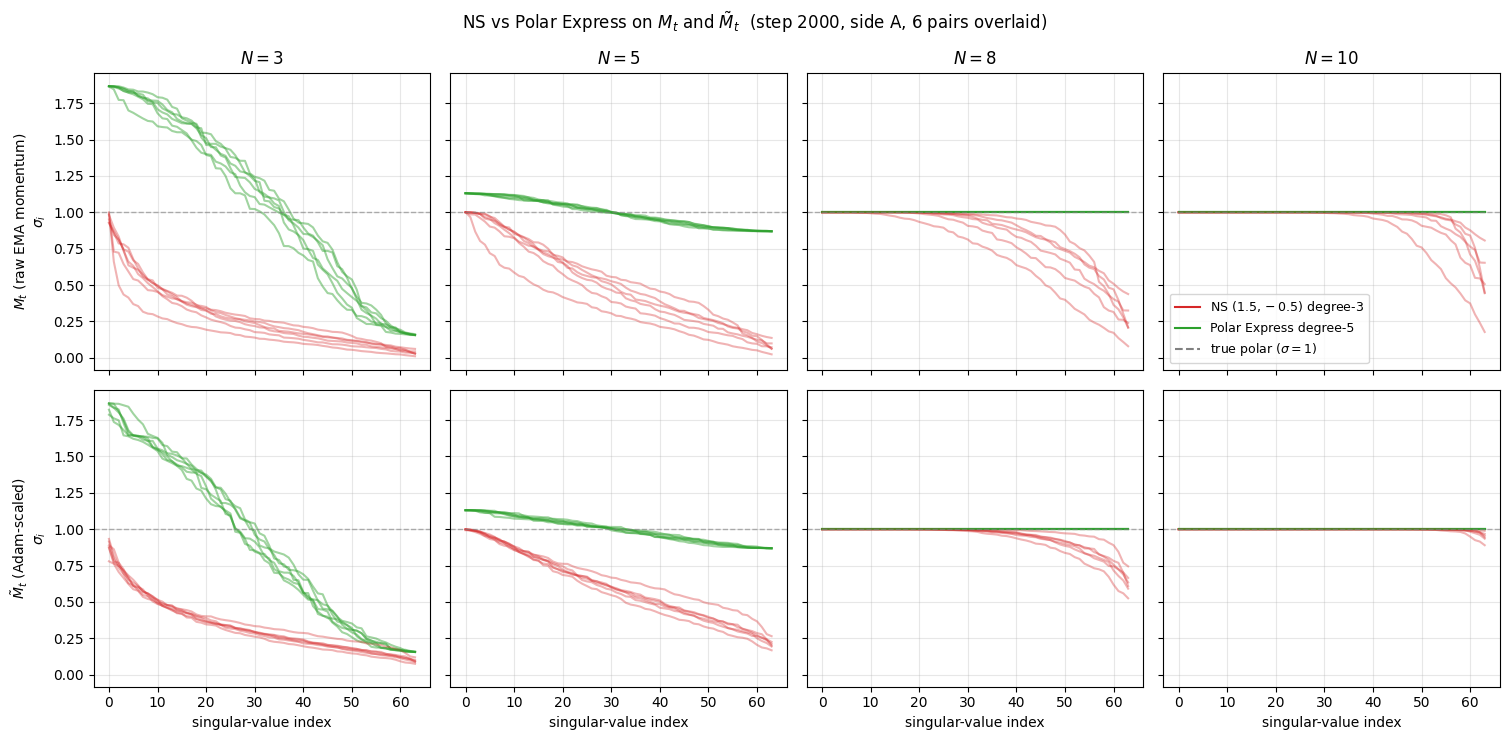

In [8]:
# Polar Express (PE) iteration — Amsel et al. 2025, Implementation 1.
# Uses the canonical implementation in lora_playground.optim so the
# visualization tracks production code; both _newton_schulz and
# _polar_express there use the small-side Gram form (Dao 2026, equiv).
from lora_playground.optim import _polar_express

def polar_express(M, K=5):
    return _polar_express(M, nsteps=K)

def plot_pe_vs_ns_M_vs_Mtilde(step, pair_indices=None, n_pairs=6, side='A',
                              Ks=(3, 5, 8, 10)):
    """Overlay NS and PE on M_t (raw EMA) and on Mtilde (Adam-scaled) at matched K."""
    snap = load_snapshot(step)
    n_total = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)

    fig, axes = plt.subplots(2, len(Ks), figsize=(3.8 * len(Ks), 7.5),
                             sharey=True, sharex=True)
    for row, (input_kind, label) in enumerate([
        ('M',  r'$M_t$ (raw EMA momentum)'),
        ('Mt', r'$\tilde M_t$ (Adam-scaled)'),
    ]):
        for ax, K in zip(axes[row], Ks):
            for pi in pair_indices:
                p = snap['pair_state'][int(pi)]
                X = (p[f'm_{side}'].float() if input_kind == 'M'
                     else Mtilde(p, side, bias_correct=False))
                s_ns = torch.linalg.svdvals(newton_schulz_polar(X, K)).numpy()
                s_pe = torch.linalg.svdvals(polar_express(X, K)).numpy()
                ax.plot(s_ns, color='C3', alpha=0.35)
                ax.plot(s_pe, color='C2', alpha=0.45)
            ax.axhline(1.0, ls='--', color='gray', alpha=0.6, lw=1)
            if row == 0:
                ax.set_title(f'$N = {K}$')
            ax.grid(True, alpha=0.3)
        axes[row, 0].set_ylabel(label + '\n' + r'$\sigma_i$')
    for ax in axes[-1]:
        ax.set_xlabel('singular-value index')
    from matplotlib.lines import Line2D
    axes[0, -1].legend([Line2D([], [], color='C3'),
                        Line2D([], [], color='C2'),
                        Line2D([], [], color='gray', ls='--')],
                       [r'NS $(1.5, -0.5)$ degree-3',
                        r'Polar Express degree-5',
                        r'true polar ($\sigma = 1$)'],
                       loc='lower left', fontsize=9)
    fig.suptitle(rf'NS vs Polar Express on $M_t$ and $\tilde M_t$  '
                 rf'(step {step}, side {side}, {n_pairs} pairs overlaid)')
    fig.tight_layout()
    return fig

plot_pe_vs_ns_M_vs_Mtilde(2000, n_pairs=6, side='A', Ks=(3, 5, 8, 10))
plt.show()


## Cross-run spectrum comparison: lr = 3e-2 (r=64, NS=5) vs lr = 1e-1 (r=256, NS=10)

The two snapshot dirs differ in **four** axes simultaneously — not just lr:

| axis              | run A          | run B               |
|-------------------|----------------|---------------------|
| lr                | 3e-2           | 1e-1                |
| lora_r            | 64             | 256                 |
| muon_ns_steps     | 5              | 10                  |
| optimizer variant | `chord-tight`  | `chord-tight-clean` |

So any spectrum difference confounds rank, NS-K, and the chord-tight-clean fix on top of lr. We plot both on a **normalized x-axis** $i/r$ so the rank difference doesn't distort the visual shape; per-curve legends carry the raw $r$.


Active RUNS:
  ('3e-2', 64, 5, 'chord-tight')
  ('1e-1', 64, 5, 'chord-tight')
  ('1e-3', 256, 10, 'chord-tight-clean')
  ('1e-1', 256, 10, 'chord-tight-clean')


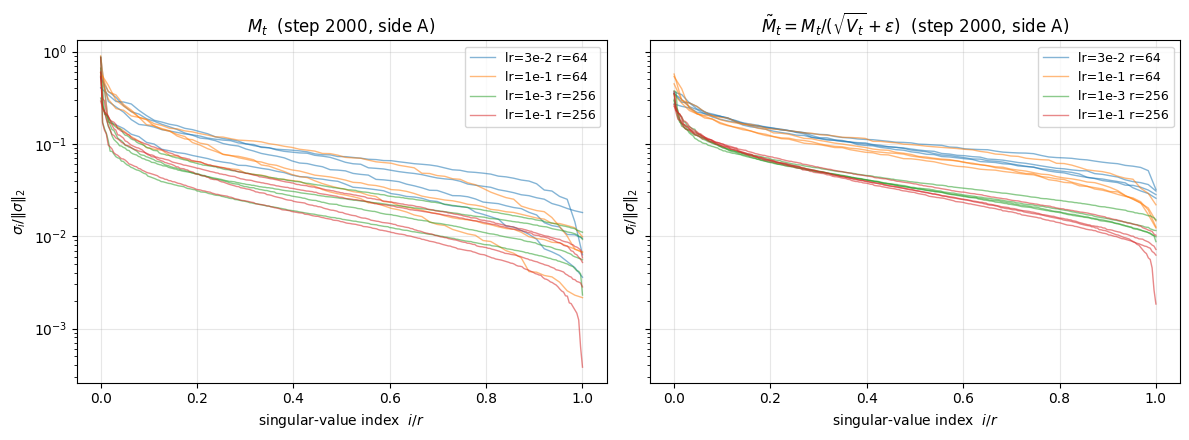

In [9]:
# RUN_A/RUN_B/RUN_C/RUN_D and RUNS live in lora_playground.snapshot_analysis.
# Local plotting helper:
_COLORS = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']

print('Active RUNS:')
for r in RUNS:
    print(f'  {r}')

def plot_spectra_compare(step, n_pairs_to_plot=4, side='A'):
    """Overlay M_t and Mtilde spectra across RUNS at a matched step."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for run_key, color in zip(RUNS, _COLORS):
        root = SNAP_ROOTS[run_key]
        snap = load_snapshot(step, root=root)
        n = len(snap['pair_state'])
        idxs = np.linspace(0, n - 1, n_pairs_to_plot, dtype=int)
        for j, pi in enumerate(idxs):
            p = snap['pair_state'][int(pi)]
            x1, s_M  = normalized_sigmas_x(p[f'm_{side}'])
            x2, s_Mt = normalized_sigmas_x(Mtilde(p, side, bias_correct=False))
            lbl = f'lr={run_key[0]} r={run_key[1]}' if j == 0 else None
            axes[0].plot(x1, s_M,  color=color, alpha=0.55, lw=1, label=lbl)
            axes[1].plot(x2, s_Mt, color=color, alpha=0.55, lw=1, label=lbl)
    axes[0].set_title(f'$M_t$  (step {step}, side {side})')
    axes[1].set_title(f'$\\tilde M_t = M_t / (\\sqrt{{V_t}} + \\varepsilon)$  (step {step}, side {side})')
    for ax in axes:
        ax.set_yscale('log')
        ax.set_xlabel('singular-value index  $i/r$')
        ax.set_ylabel(r'$\sigma_i / \|\sigma\|_2$')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
    fig.tight_layout()
    return fig

plot_spectra_compare(2000, n_pairs_to_plot=4, side='A')
plt.show()


### NS iteration sweep on both runs

Run Newton-Schulz at $N_s \\in \\{1, 3, 5, 10\\}$ on $M_t$ and $\\tilde M_t$ from each run separately. Columns = $N_s$, rows = (run A, run B). Within each panel: red = NS on $M_t$, blue = NS on $\\tilde M_t$. Dashed gray = true polar target $\\sigma = 1$.

If $\\tilde M_t$ at lr=1e-1 already sits near the dead-zone shoulder, NS-K=10 won't pull it to 1 — that's the structural signal motivating the chord-tight-clean / spectral fix.


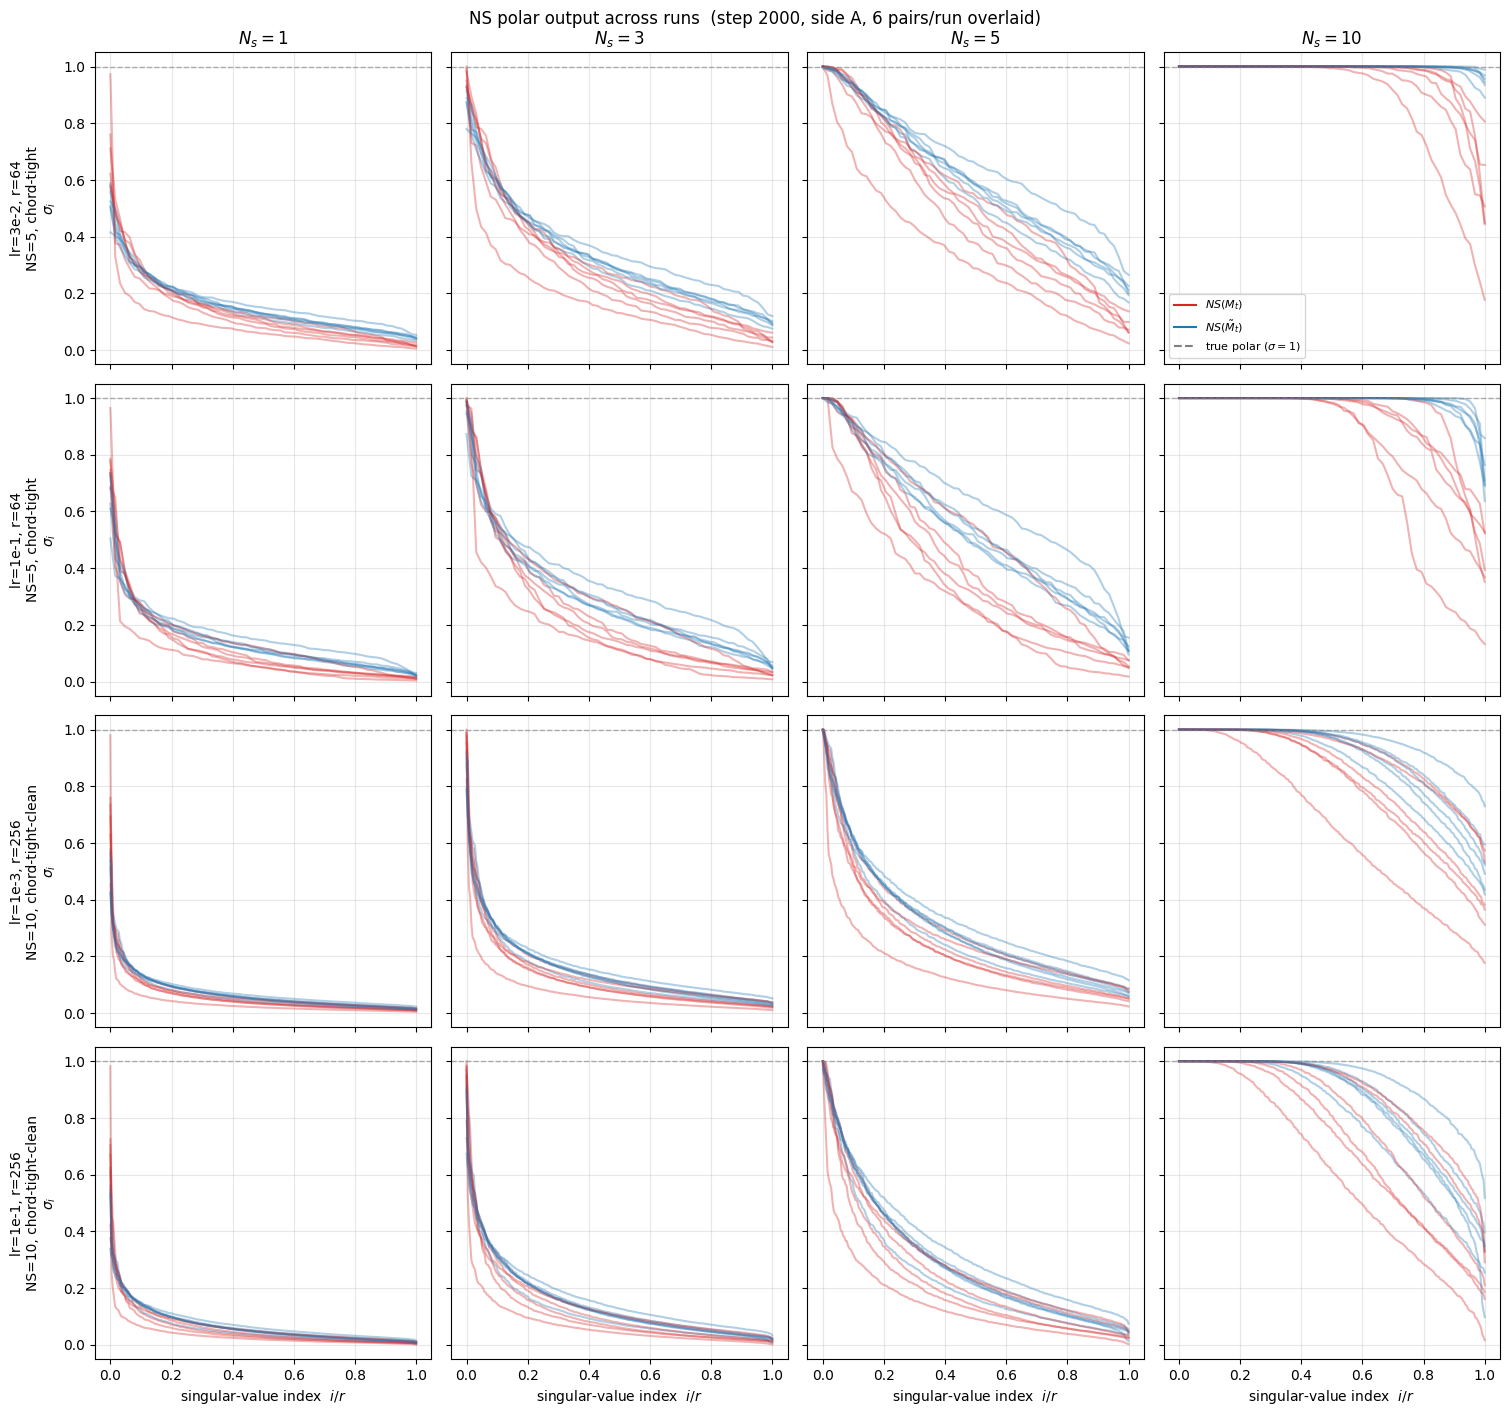

In [10]:
def plot_ns_compare_runs(step, n_pairs=6, side='A', Ks=(1, 3, 5, 10)):
    runs = RUNS
    fig, axes = plt.subplots(len(runs), len(Ks),
                              figsize=(3.8 * len(Ks), 3.6 * len(runs)),
                              sharex=True, sharey=True)
    for row, run_key in enumerate(runs):
        root = SNAP_ROOTS[run_key]
        snap = load_snapshot(step, root=root)
        n_total = len(snap['pair_state'])
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)
        for col, K in enumerate(Ks):
            ax = axes[row, col]
            for pi in pair_indices:
                p = snap['pair_state'][int(pi)]
                M  = p[f'm_{side}'].float()
                Mt = Mtilde(p, side, bias_correct=False)
                s_M  = torch.linalg.svdvals(newton_schulz_polar(M,  K)).numpy()
                s_Mt = torch.linalg.svdvals(newton_schulz_polar(Mt, K)).numpy()
                xM  = np.arange(len(s_M))  / max(len(s_M)  - 1, 1)
                xMt = np.arange(len(s_Mt)) / max(len(s_Mt) - 1, 1)
                ax.plot(xM,  s_M,  color='C3', alpha=0.35)
                ax.plot(xMt, s_Mt, color='C0', alpha=0.35)
            ax.axhline(1.0, ls='--', color='gray', alpha=0.6, lw=1)
            if row == 0:
                ax.set_title(f'$N_s = {K}$')
            if col == 0:
                ax.set_ylabel(f'lr={run_key[0]}, r={run_key[1]}\n'
                              f'NS={run_key[2]}, {run_key[3]}\n'
                              r'$\sigma_i$')
            if row == len(runs) - 1:
                ax.set_xlabel('singular-value index  $i/r$')
            ax.grid(True, alpha=0.3)
    from matplotlib.lines import Line2D
    axes[0, -1].legend([Line2D([], [], color='C3'),
                        Line2D([], [], color='C0'),
                        Line2D([], [], color='gray', ls='--')],
                       [r'$NS(M_t)$',
                        r'$NS(\tilde M_t)$',
                        r'true polar ($\sigma = 1$)'],
                       loc='lower left', fontsize=8)
    fig.suptitle(f'NS polar output across runs  (step {step}, side {side}, '
                 f'{n_pairs} pairs/run overlaid)')
    fig.tight_layout()
    return fig

plot_ns_compare_runs(2000, n_pairs=6, side='A', Ks=(1, 3, 5, 10))
plt.show()